## Análisis Exploratorio de Datos
# Objetivos
-Analizar los datos  
-Observar Correlaciones  
-Observar insigth y gráficas  
-Desarrollo de PCA y Kernel PCA  
-KMeans y DBScan  
Este notebook contiene el análisis del dataset `seismic_data.csv`, abarcando limpieza, análisis exploratorio, reducción de dimensionalidad (PCA y Kernel PCA) y clustering (KMeans y DBSCAN).

## 1. Analizar los datos

In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Cargar los datos
df = pd.read_csv('seismic_data.csv')

# Mostrar las primeras filas
display(df.head())

# Información general del dataset
print("\n--- Información del Dataset ---")
df.info()

# Resumen estadístico
print("\n--- Resumen Estadístico ---")
display(df.describe())

# Revisar valores nulos
print("\n--- Valores Nulos por Columna ---")
display(df.isnull().sum())


,Seismic Zone,PGA (m/s²),PGV (m/s),PGD (m),Spectral Acceleration (g),Soil Type,Site Amplification Factor,Historical Earthquake Magnitude (Mw),Fault Distance (km),Seismic Wave Frequency (Hz),...,Mass of Structure (kg),Axial Stiffness (kN/m),Bending Stiffness (kN·m²),Lateral Load Resisting System,Predicted Max Inter-Story Drift Ratio (%),Predicted Max Roof Displacement (m),Predicted Base Shear Force (kN),Predicted Structural Acceleration (m/s²),Predicted Damage Index (0–1 Scale),Predicted Collapse Probability (%)
0,High,0.378901,0.312027,0.057183,0.634076,Sand,0.939157,6.875154,22.203449,1.683141,...,737892.380634,3150.171653,25771.750960,Moment Frame,2.126096,0.839807,3927.940393,0.767494,0.804542,80.454180
1,Very High,1.346301,1.255807,0.204481,1.728551,Clay,1.089761,6.829334,6.947244,4.041680,...,68704.846377,3245.337590,32856.944998,Moment Frame,2.880256,1.530932,2923.719143,1.848156,0.706411,70.641053
2,Low,0.502373,0.633995,0.443304,0.156820,Rock,2.689239,7.100447,33.224830,5.841681,...,705858.693050,7518.106276,16777.171277,Moment Frame,2.762881,0.796000,180.446916,4.455967,0.795635,79.563529
3,High,0.614900,0.429642,0.024551,1.085648,Rock,2.194323,7.871919,15.225075,9.485727,...,937792.307484,781.139234,3013.866452,Braced Frame,2.965618,1.303857,4136.426423,3.787915,0.766775,76.677520
4,High,0.181329,0.821528,0.480747,0.383056,Rock,1.357043,8.841107,71.283374,0.780634,...,728244.975835,4118.984745,25287.554733,Braced Frame,0.819418,1.519645,926.867918,1.460147,0.205368,20.536788



--- Información del Dataset ---
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 26 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   Seismic Zone                               1000 non-null   str    
 1   PGA (m/s²)                                 1000 non-null   float64
 2   PGV (m/s)                                  1000 non-null   float64
 3   PGD (m)                                    1000 non-null   float64
 4   Spectral Acceleration (g)                  1000 non-null   float64
 5   Soil Type                                  1000 non-null   str    
 6   Site Amplification Factor                  1000 non-null   float64
 7   Historical Earthquake Magnitude (Mw)       1000 non-null   float64
 8   Fault Distance (km)                        1000 non-null   float64
 9   Seismic Wave Frequency (Hz)                1000 non-null   float64
 10  Bui

,PGA (m/s²),PGV (m/s),PGD (m),Spectral Acceleration (g),Site Amplification Factor,Historical Earthquake Magnitude (Mw),Fault Distance (km),Seismic Wave Frequency (Hz),Building Height (m),Number of Stories,...,Damping Ratio (%),Mass of Structure (kg),Axial Stiffness (kN/m),Bending Stiffness (kN·m²),Predicted Max Inter-Story Drift Ratio (%),Predicted Max Roof Displacement (m),Predicted Base Shear Force (kN),Predicted Structural Acceleration (m/s²),Predicted Damage Index (0–1 Scale),Predicted Collapse Probability (%)
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,...,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,0.793573,1.041248,0.246805,0.944878,1.878052,6.678788,49.480579,5.123714,103.853375,24.260000,...,5.510258,531806.469146,5236.853352,24763.822253,2.513783,1.010999,2523.310399,2.499381,0.511766,51.176552
std,0.404761,0.542268,0.144252,0.493144,0.627568,1.291690,27.609706,2.854406,56.050832,14.291629,...,2.591786,273015.576371,2700.421003,13868.872032,1.427768,0.575256,1432.973815,1.432013,0.285527,28.552668
min,0.100016,0.100058,0.001113,0.106661,0.800530,4.501093,1.005230,0.102385,5.478644,1.000000,...,1.002166,58381.459484,501.667401,1020.733299,0.104201,0.010018,51.648191,0.104728,0.001235,0.123452
25%,0.440274,0.577084,0.124932,0.513884,1.331654,5.554194,26.981651,2.613522,57.165484,12.000000,...,3.247773,301806.971471,2932.127304,12851.803915,1.188688,0.519939,1251.996728,1.280252,0.265685,26.568456
50%,0.795659,1.050815,0.238077,0.941010,1.862688,6.590863,49.727692,5.140098,103.728764,24.000000,...,5.582594,525536.492470,5191.662152,24367.727370,2.516454,1.017967,2521.754786,2.444797,0.503805,50.380498
75%,1.147708,1.494989,0.371176,1.383971,2.404483,7.775560,72.516244,7.622953,153.335766,36.000000,...,7.687155,767059.845222,7383.113325,36536.253802,3.727959,1.502006,3773.988326,3.782687,0.763089,76.308887
max,1.499381,1.995724,0.499398,1.799083,2.998256,8.985075,99.863115,9.995101,199.936275,49.000000,...,9.998350,999898.033370,9974.978725,49843.933827,4.993744,1.999393,4997.439385,4.994814,0.999518,99.951813



--- Valores Nulos por Columna ---


Seismic Zone                                 0
PGA (m/s²)                                   0
PGV (m/s)                                    0
PGD (m)                                      0
Spectral Acceleration (g)                    0
Soil Type                                    0
Site Amplification Factor                    0
Historical Earthquake Magnitude (Mw)         0
Fault Distance (km)                          0
Seismic Wave Frequency (Hz)                  0
Building Height (m)                          0
Number of Stories                            0
Structural Material                          0
Foundation Type                              0
Natural Frequency (Hz)                       0
Damping Ratio (%)                            0
Mass of Structure (kg)                       0
Axial Stiffness (kN/m)                       0
Bending Stiffness (kN·m²)                    0
Lateral Load Resisting System                0
Predicted Max Inter-Story Drift Ratio (%)    0
Predicted Max

## 2. Observar Correlaciones

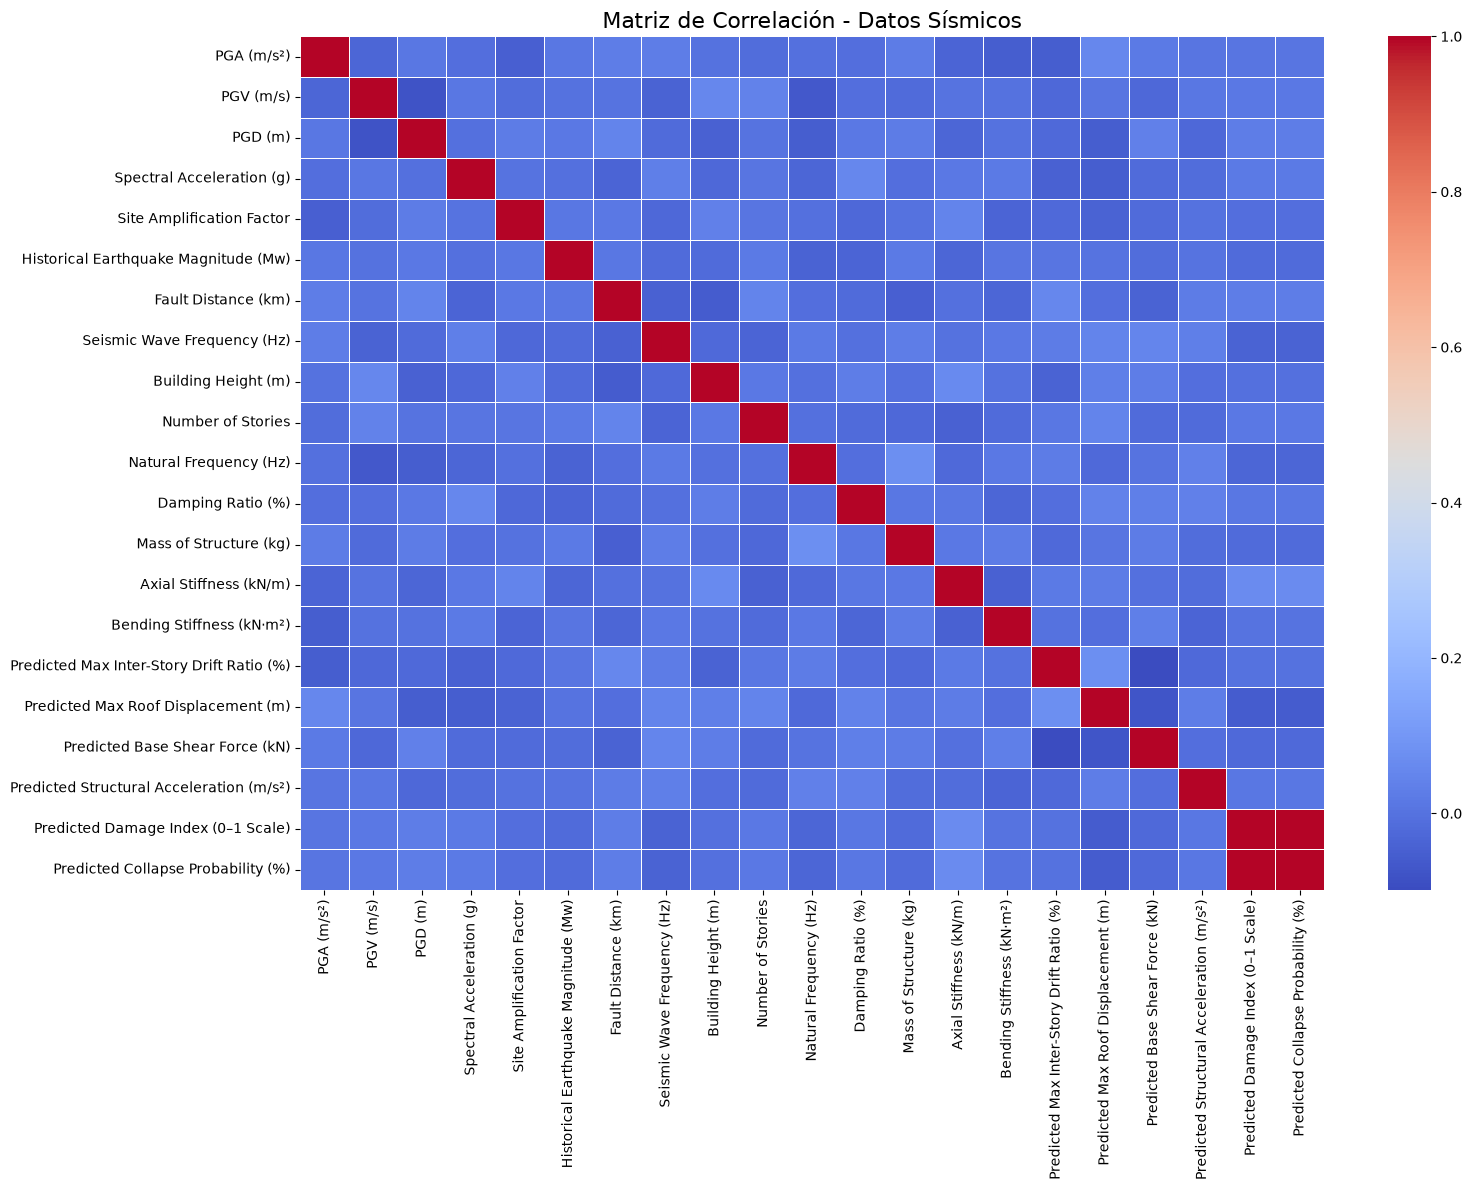


Correlación con 'Predicted Collapse Probability (%)':


,Predicted Collapse Probability (%)
Predicted Collapse Probability (%),1.000000
Predicted Damage Index (0–1 Scale),1.000000
Axial Stiffness (kN/m),0.065536
PGD (m),0.027669
Fault Distance (km),0.026029
Spectral Acceleration (g),0.018360
Number of Stories,0.015146
PGV (m/s),0.013637
Predicted Structural Acceleration (m/s²),0.012779
Damping Ratio (%),0.012152


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(16, 12))

# Seleccionar solo columnas numéricas para la matriz de correlación
numeric_df = df.select_dtypes(include=[np.number])
correlation_matrix = numeric_df.corr()

# Dibujar el mapa de calor
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', linewidths=0.5)
plt.title('Matriz de Correlación - Datos Sísmicos', fontsize=16)
plt.tight_layout()
plt.show()

# Mostrar las correlaciones más fuertes con la Probabilidad de Colapso
target_col = 'Predicted Collapse Probability (%)'
if target_col in correlation_matrix.columns:
    target_corr = correlation_matrix[target_col].sort_values(ascending=False)
    print(f"\nCorrelación con '{target_col}':")
    display(target_corr.to_frame())


## 3. Observar Insights y Gráficos

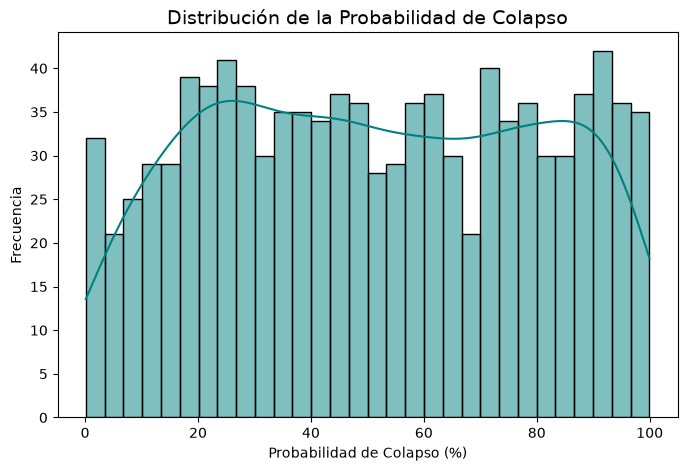

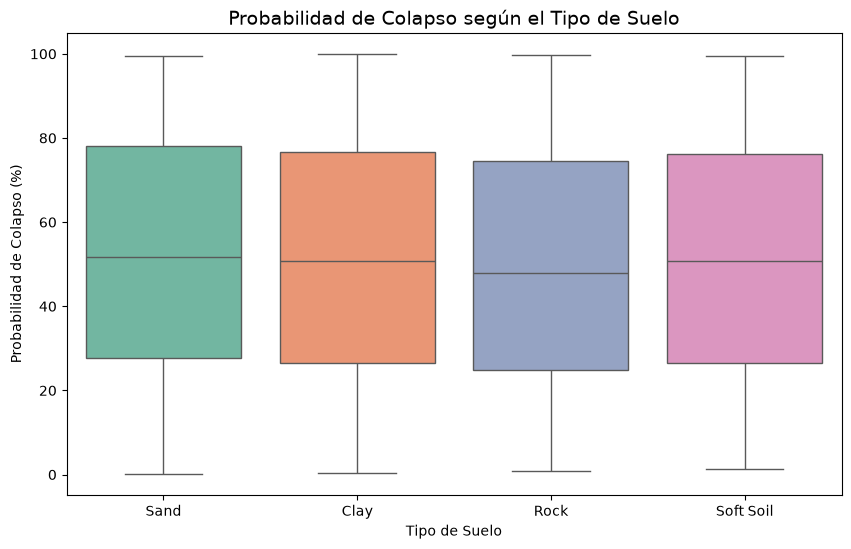

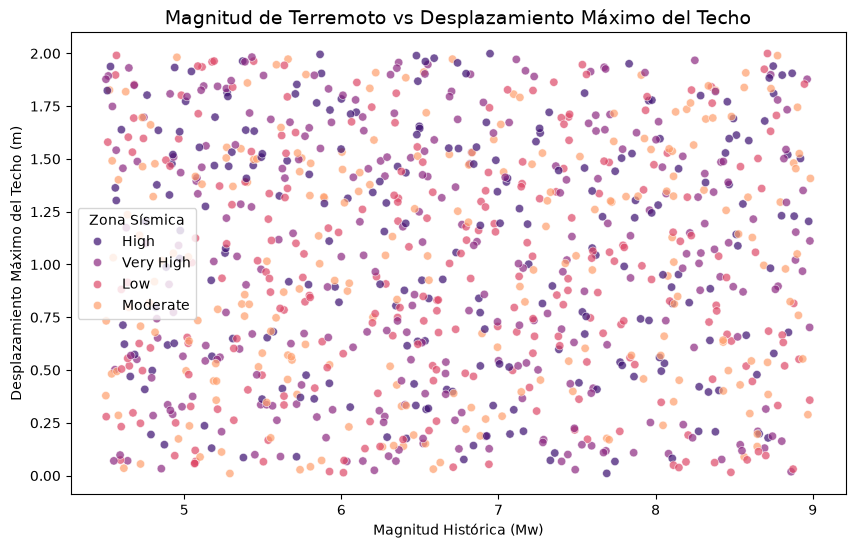

In [3]:
# Distribución de la Probabilidad de Colapso
plt.figure(figsize=(8, 5))
sns.histplot(df['Predicted Collapse Probability (%)'], bins=30, kde=True, color='teal')
plt.title('Distribución de la Probabilidad de Colapso', fontsize=14)
plt.xlabel('Probabilidad de Colapso (%)')
plt.ylabel('Frecuencia')
plt.show()

# Boxplot de Probabilidad de Colapso por Tipo de Suelo
plt.figure(figsize=(10, 6))
sns.boxplot(x='Soil Type', y='Predicted Collapse Probability (%)', data=df, palette='Set2')
plt.title('Probabilidad de Colapso según el Tipo de Suelo', fontsize=14)
plt.xlabel('Tipo de Suelo')
plt.ylabel('Probabilidad de Colapso (%)')
plt.show()

# Scatter plot: Magnitud Histórica vs Desplazamiento del Techo
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Historical Earthquake Magnitude (Mw)', y='Predicted Max Roof Displacement (m)', hue='Seismic Zone', data=df, palette='magma', alpha=0.7)
plt.title('Magnitud de Terremoto vs Desplazamiento Máximo del Techo', fontsize=14)
plt.xlabel('Magnitud Histórica (Mw)')
plt.ylabel('Desplazamiento Máximo del Techo (m)')
plt.legend(title='Zona Sísmica')
plt.show()


## 4. Desarrollo de PCA y Kernel PCA

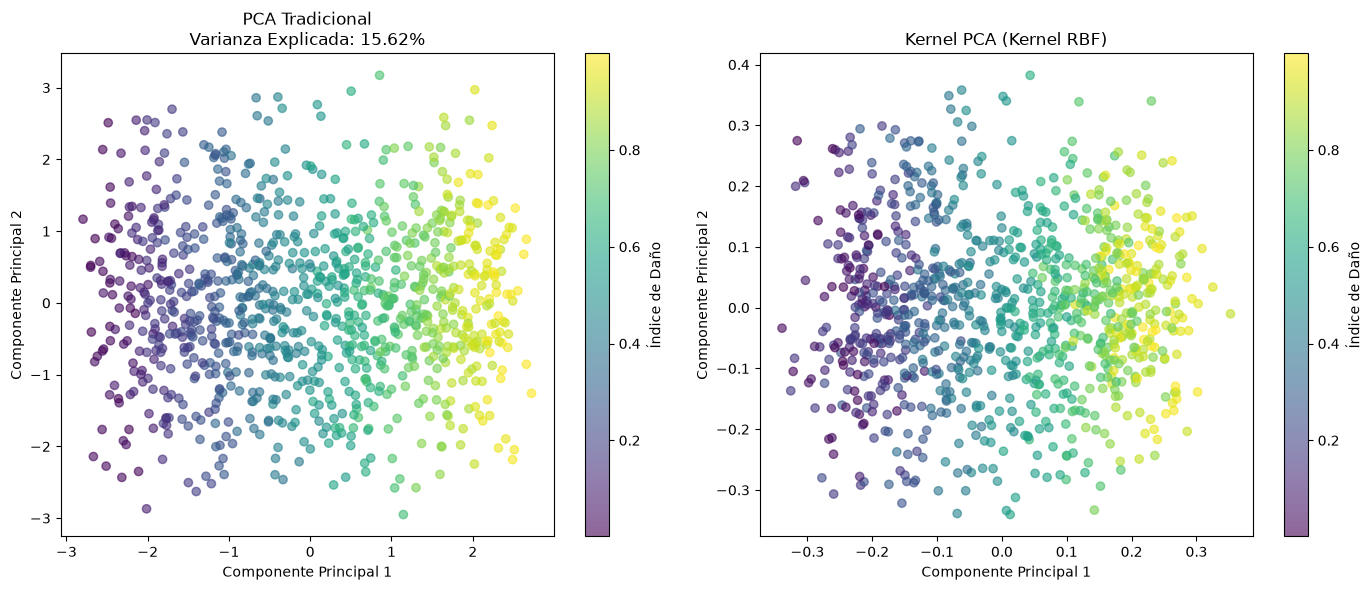

In [4]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA, KernelPCA

# Preprocesamiento: Usaremos solo las características numéricas y estandarizaremos
X_num = numeric_df.fillna(numeric_df.mean()) # Imputar nulos con la media si existen
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_num)

# --- PCA Tradicional ---
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
scatter1 = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df['Predicted Damage Index (0–1 Scale)'], cmap='viridis', alpha=0.6)
plt.colorbar(scatter1, label='Índice de Daño')
plt.title(f'PCA Tradicional\nVarianza Explicada: {pca.explained_variance_ratio_.sum():.2%}')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')

# --- Kernel PCA (usando RBF) ---
# Usamos gamma=0.05 y fit_inverse_transform=False para optimizar
kpca = KernelPCA(n_components=2, kernel='rbf', gamma=0.05, fit_inverse_transform=False)
X_kpca = kpca.fit_transform(X_scaled)

plt.subplot(1, 2, 2)
scatter2 = plt.scatter(X_kpca[:, 0], X_kpca[:, 1], c=df['Predicted Damage Index (0–1 Scale)'], cmap='viridis', alpha=0.6)
plt.colorbar(scatter2, label='Índice de Daño')
plt.title('Kernel PCA (Kernel RBF)')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')

plt.tight_layout()
plt.show()


## 5. KMeans y DBSCAN

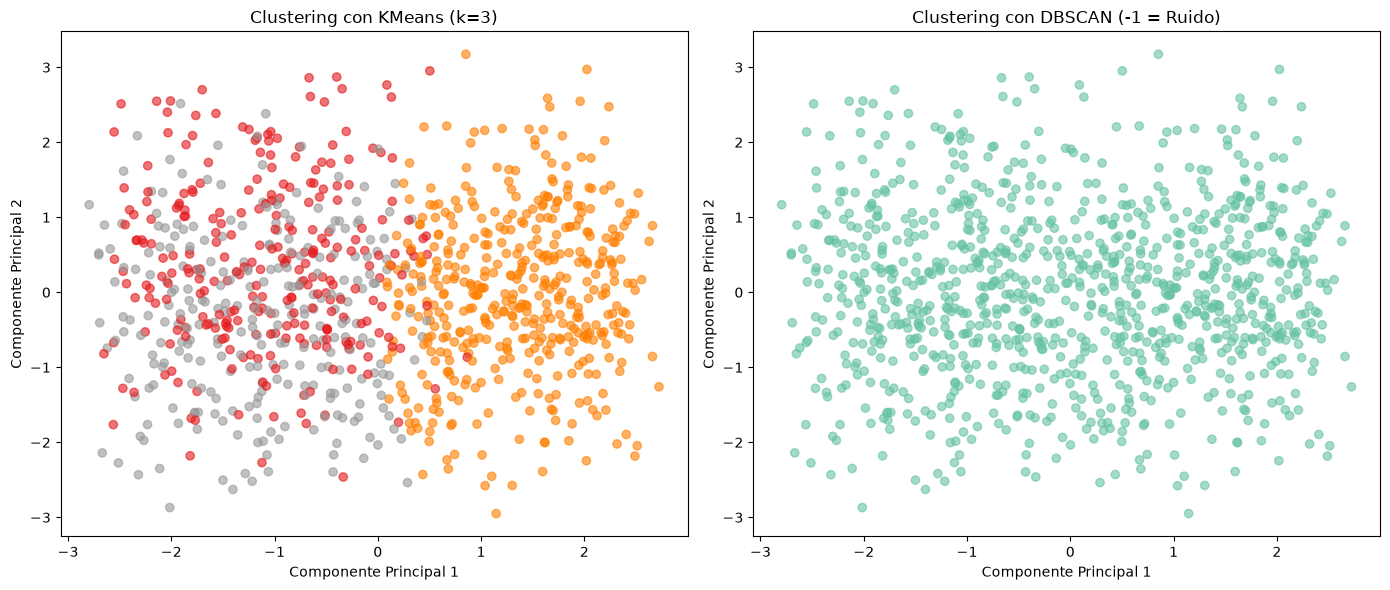

--- Evaluación de Clusters ---
Silhouette Score (KMeans): 0.0498
DBSCAN agrupó todo como ruido o en un solo cluster (ajustar eps). 


In [5]:
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score

# --- KMeans ---
# Determinamos 3 clusters (por ejemplo: bajo, medio, alto riesgo)
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans_labels = kmeans.fit_predict(X_scaled)

# --- DBSCAN ---
# Parámetros eps y min_samples ajustables
dbscan = DBSCAN(eps=3.5, min_samples=10)
dbscan_labels = dbscan.fit_predict(X_scaled)

# Graficar resultados usando los componentes de PCA para visualización 2D
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels, cmap='Set1', alpha=0.6)
plt.title('Clustering con KMeans (k=3)')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')

plt.subplot(1, 2, 2)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=dbscan_labels, cmap='Set2', alpha=0.6)
plt.title('Clustering con DBSCAN (-1 = Ruido)')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')

plt.tight_layout()
plt.show()

# Evaluar calidad del clustering
print("--- Evaluación de Clusters ---")
if len(set(kmeans_labels)) > 1:
    print(f"Silhouette Score (KMeans): {silhouette_score(X_scaled, kmeans_labels):.4f}")
    
valid_dbscan_mask = dbscan_labels != -1
if len(set(dbscan_labels[valid_dbscan_mask])) > 1:
    print(f"Silhouette Score (DBSCAN - sin ruido): {silhouette_score(X_scaled[valid_dbscan_mask], dbscan_labels[valid_dbscan_mask]):.4f}")
else:
    print("DBSCAN agrupó todo como ruido o en un solo cluster (ajustar eps). ")
